In [2]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../../Projektdatensaetze/2023/Fahrradzaehlstellen2023_stuendlich_RENAMED.csv',
                 sep=';')

df['time'] = pd.to_datetime(df['time'], format='%d.%m.%Y %H:%M')
df['days'] = df['time'].dt.date
df_day = df.groupby('days')['5.02 BN - Kennedybrücke (Südseite) Barometer'].sum()
df_day = pd.DataFrame(df_day)
display(df_day)


,5.02 BN - Kennedybrücke (Südseite) Barometer
days,
2023-01-01,1335.0
2023-01-02,2294.0
2023-01-03,4115.0
2023-01-04,3278.0
2023-01-05,3870.0
...,...
2023-12-27,2374.0
2023-12-28,3022.0
2023-12-29,2413.0


In [3]:
#prüfe auf Stationarität
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_day)
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -1.4963
p-value = 0.5354


Datenaufbereitung

1. Vergleiche Autokorrelation vs. partielle Autokorrelation
2. teile in Trainings- und Testdaten ein
3. Stelle Stationarität her

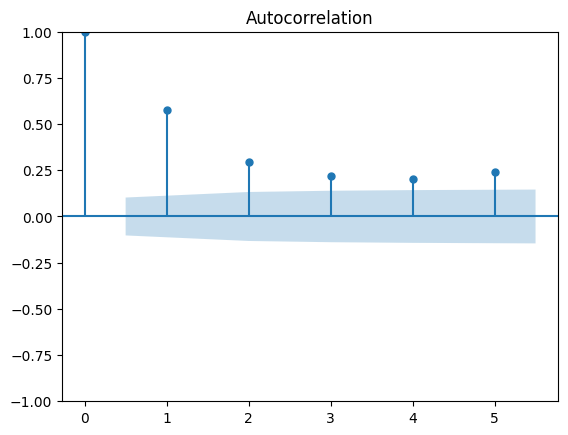

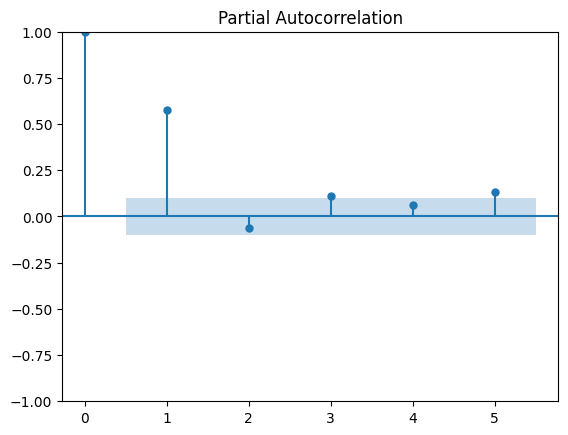

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_day, lags=5)
plot_pacf(df_day, lags=5)
plt.show()

In [41]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_day) * 0.9)
df_train = df_day.iloc[:end_train]
df_test = df_day.iloc[end_train:]
display(df_train)


,5.02 BN - Kennedybrücke (Südseite) Barometer
days,
2023-01-01,1335.0
2023-01-02,2294.0
2023-01-03,4115.0
2023-01-04,3278.0
2023-01-05,3870.0
...,...
2023-11-21,4899.0
2023-11-22,5210.0
2023-11-23,5212.0


In [51]:
#logarithmiere die Daten vor Stationaritätsherstellung

df_train['close_log'] = np.log(df_train['5.02 BN - Kennedybrücke (Südseite) Barometer'])
display(df_train)

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_7900\1799423694.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['close_log'] = np.log(df_train['5.02 BN - Kennedybrücke (Südseite) Barometer'])


,5.02 BN - Kennedybrücke (Südseite) Barometer,close_log
days,,
2023-01-01,1335.0,7.196687
2023-01-02,2294.0,7.738052
2023-01-03,4115.0,8.322394
2023-01-04,3278.0,8.094989
2023-01-05,3870.0,8.261010
...,...,...
2023-11-21,4899.0,8.496786
2023-11-22,5210.0,8.558335
2023-11-23,5212.0,8.558719


In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
arima = SARIMAX(df_train['close_log'], order=(1,0,0))
result = arima.fit()
result.summary()

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              close_log   No. Observations:                  329
Model:               SARIMAX(1, 5, 0)   Log Likelihood                -742.468
Date:                Sat, 30 Nov 2024   AIC                           1488.935
Time:                        16:16:42   BIC                           1496.497
Sample:                    01-01-2023   HQIC                          1491.953
                         - 11-25-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7774      0.030    -25.628      0.000      -0.837      -0.718
sigma2         5.7114      0.404     14.121      0.000       4.919       6.504
===================================================================================
Ljung-Box (L1) (Q):                  83.63   Jarque-Bera (JB):                22.14
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.58   Skew:                            -0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              close_log   No. Observations:                  329
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -127.661
Date:                Sat, 30 Nov 2024   AIC                            259.323
Time:                        16:14:41   BIC                            266.909
Sample:                    01-01-2023   HQIC                           262.349
                         - 11-25-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9027      0.027    -32.926      0.000      -0.956      -0.849
sigma2         0.1269      0.008     15.719      0.000       0.111       0.143
===================================================================================
Ljung-Box (L1) (Q):                  21.80   Jarque-Bera (JB):                75.05
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.55   Skew:                            -1.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""